In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [16]:
# input from excel:
excel_filename = "reservoir_data.xlsx"
try:
    # Read Parameters Sheet
    df_params = pd.read_excel(excel_filename, sheet_name='Parameters')
    params = dict(zip(df_params['Parameter'], df_params['Value']))

    # Read Production History Sheet
    df_history = pd.read_excel(excel_filename, sheet_name='Production_History')
    
    print(" Successfully loaded 'reservoir_data.xlsx' data sheets.")
except Exception as e:
    raise FileNotFoundError(f"Error loading Excel file. Make sure 'reservoir_data.xlsx' exists and is closed: {e}")

api = params['api_gravity']
sg_gas = params['gas_gravity']
temp_f = params['temperature']
rsi = params['initial_gor']
pi = params['initial_pressure']
co = params['co']
m = params.get('m', 0.3)
cf = params.get('cf', 4.0e-6)
cw = params.get('cw', 3.0e-6)
swi = params.get('swi', 0.20)  


 Successfully loaded 'reservoir_data.xlsx' data sheets.


In [17]:
# Black oil PVT prop calculator through standing correlation
# We used standing correlation because it is widely used in the industries. We will be doing the project for black oil

class BlackOilPVT:
    def __init__(self,api,sg_gas,temp_f,rsi,co):
        self.api = api #API Gravity
        self.sg_gas = sg_gas # separator gas gravity
        self.temp_f = temp_f
        self.temp_r = temp_f + 460  # Convert Fahrenheit to Rankine
        self.rsi = rsi
        self.sg_oil = 141.5 / (api + 131.5)
        self.co=co # isothermal compressibility

    
        #Pb calculation:
        a=0.00091*((self.temp_f)-0.0125*(self.api))
        self.pb = 18.2 * (((self.rsi / self.sg_gas) ** 0.83) * (10 ** a) - 1.4)

    def calculate_z_factor(self, p):
       
        if p <= 0:
            return 1.0
            
        # 1. Sutton's Pseudo-critical properties (1985)
        ppc = 756.8 - 131.0 * self.sg_gas - 3.6 * (self.sg_gas ** 2)
        tpc = 169.2 + 349.5 * self.sg_gas - 74.0 * (self.sg_gas ** 2)
        
        # 2. Pseudo-reduced properties
        pr = max(0.01, p / ppc)
        tr = max(1.05, self.temp_r / tpc)  # Guard to prevent tr <= 0.92 boundary errors
        
        # 3. Beggs & Brill explicit coefficients
        a = 1.39 * (tr - 0.92) ** 0.5 - 0.36 * tr - 0.101
        
        e = 9.0 * (tr - 1.0)
        b = (0.62 - 0.23 * tr) * pr + (0.066 / (tr - 0.86) - 0.03) * (pr ** 2) + (0.32 * (pr ** 6)) / (10 ** e)
        
        c = 0.132 - 0.32 * np.log10(tr)
        d = 10 ** (0.3106 - 0.49 * tr + 0.1824 * (tr ** 2))
        
        z = a + (1.0 - a) * np.exp(-b) + c * (pr ** d)
        return max(0.2, z)  # Keep Z within physically realistic natural gas bounds

    def calculate_rs(self,p):
            if p>self.pb:
                return self.rsi # Rs will be constant above bubble point
            else:
                a=0.00091*((self.temp_f)-0.0125*(self.api))
                x=(-a)
                rs = self.sg_gas * (((p / 18.2) + 1.4) * (10 ** x)) ** (1.2048)
                return max(0.1,rs)
        
    def calculate_bo(self,p):
            rs=self.calculate_rs(p)
            f = rs * (self.sg_gas / self.sg_oil) ** 0.5 + 1.25 * self.temp_f
            bo_under = 0.9759 + 0.000120 * (f ** 1.2)

            # standing correlation is valide for <=Pb
            if p<=self.pb:
                return bo_under
            else:
                 return bo_under * np.exp(-self.co * (p - self.pb))
        
    def calculate_bg(self,p):
            z= self.calculate_z_factor(p)
            bg=0.02827*(z*self.temp_r)/p/5.615 # in bbl/scf
            return bg

In [18]:

pvt=BlackOilPVT(
     api, sg_gas, temp_f, rsi, co)
print(f"\n--- PVT Verification ---")
print(f"Calculated Bubblepoint Pressure (Pb): {pvt.pb:.2f} psi")
print(f"Initial Bo (Boi) at {pi} psi: {pvt.calculate_bo(pi):.4f} bbl/STB")
print(f"Initial Bg (Bgi) at {pi} psi: {pvt.calculate_bg(pi):.6f} bbl/scf")



--- PVT Verification ---
Calculated Bubblepoint Pressure (Pb): 3266.54 psi
Initial Bo (Boi) at 4000.0 psi: 1.1512 bbl/STB
Initial Bg (Bgi) at 4000.0 psi: 0.000713 bbl/scf


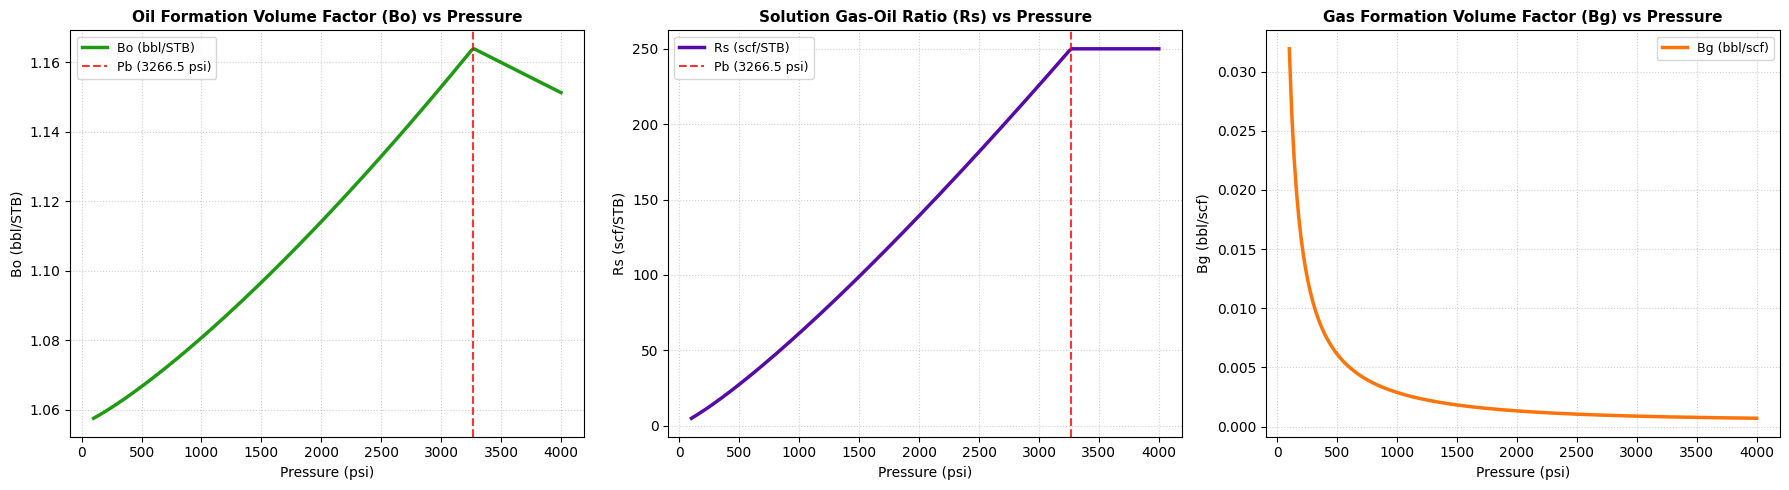

In [19]:
# visualization of Bo,Rs,Bg
pressures=np.linspace(100,pi,200)
bo_values = [pvt.calculate_bo(p) for p in pressures]
rs_values = [pvt.calculate_rs(p) for p in pressures]
bg_values = [pvt.calculate_bg(p) for p in pressures]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot Oil FVF (Bo)
ax1.plot(pressures, bo_values, color="#1F9B13", linewidth=2.5, label='Bo (bbl/STB)')
ax1.axvline(x=pvt.pb, color='red', linestyle='--', alpha=0.8, label=f'Pb ({pvt.pb:.1f} psi)')
ax1.set_title('Oil Formation Volume Factor (Bo) vs Pressure', fontsize=11, fontweight='bold')
ax1.set_xlabel('Pressure (psi)', fontsize=10)
ax1.set_ylabel('Bo (bbl/STB)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

# Plot Solution GOR (Rs)
ax2.plot(pressures, rs_values, color="#560BA7", linewidth=2.5, label='Rs (scf/STB)')
ax2.axvline(x=pvt.pb, color='red', linestyle='--', alpha=0.8, label=f'Pb ({pvt.pb:.1f} psi)')
ax2.set_title('Solution Gas-Oil Ratio (Rs) vs Pressure', fontsize=11, fontweight='bold')
ax2.set_xlabel('Pressure (psi)', fontsize=10)
ax2.set_ylabel('Rs (scf/STB)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

# Plot Gas FVF (Bg)
ax3.plot(pressures, bg_values, color="#FE740B", linewidth=2.5, label='Bg (bbl/scf)')
ax3.set_title('Gas Formation Volume Factor (Bg) vs Pressure', fontsize=11, fontweight='bold')
ax3.set_xlabel('Pressure (psi)', fontsize=10)
ax3.set_ylabel('Bg (bbl/scf)', fontsize=10)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [20]:
# MBE and drive indices:
boi=pvt.calculate_bo(pi)
bgi=pvt.calculate_bg(pi)
rsi=pvt.rsi

# Havlena Odeh MBE:
F_list=[]
Eo_list=[]
Eg_list=[]
Efw_list=[]
We_sum_list = []
cum_we_term = 0

#production data
for i,row in df_history.iterrows():
    p=row['Pressure']
    np_cum=row['Cum_Oil']
    wp_cum = row['Cum_Water']
    gp_cum=row['Cum_Gas']
    dt = row['Days'] if i == 0 else row['Days'] - df_history.loc[i-1, 'Days']
    
    bo = pvt.calculate_bo(p)
    bg = pvt.calculate_bg(p)
    rs = pvt.calculate_rs(p)
    
    # Underground fluid withdrawal (F) and oil expansion (Eo) and Eg and Efw
    F = np_cum * bo + max(0,gp_cum - np_cum*rs)*bg + wp_cum * 1.0  # Assumes Bw = 1.0 bbl/bbl
    Eo = (bo - boi) + (rsi - rs) * bg
    Eg= boi * ((bg/bgi) -1 )
    Efw= (1+m)* boi * (( cw * swi + cf)/(1 - swi)) * (pi - p)


    # Assuming steady state models we take schilithus water influx model to find thw We ( water influx) term
    cum_we_term += (pi-p)*dt # constant c is managed in overall coefficient

    #storing data:
    F_list.append(F)
    Eo_list.append(Eo)
    Eg_list.append(Eg)
    Efw_list.append(Efw)
    We_sum_list.append(cum_we_term)
df_history['F'] = F_list
df_history['Eo'] = Eo_list
df_history['Eg'] = Eg_list
df_history['Efw'] = Efw_list
df_history['We_Sum'] = We_sum_list

# We will solve the eqn F = N * (Eo + m * Eg + Efw) + C * We_Sum by linear regression
df_history['E_total'] = df_history['Eo'] + m * df_history['Eg'] + df_history['Efw']
X=np.column_stack((df_history['E_total'], df_history['We_Sum']))
y=df_history['F']

reg_results=np.linalg.lstsq(X,y,rcond=0)[0]
N_estimated = max(1e6, reg_results[0])  # Solves for OOIP (N)
C_water = max(0.0, reg_results[1])       # Solves for Water Influx constant (C)
if reg_results[0] <= 0:
    print(f" DATA WARNING: Regression solved for a non-positive OOIP ({reg_results[0]/1e6:.2f} MMSTB) "
          f"before flooring. Treat N_estimated (and any RF computed from it) as unreliable.")
if reg_results[1] < 0:
    print(f" DATA WARNING: Regression solved for a negative water-influx constant C ({reg_results[1]:.5f}). "
          f"Physically impossible - check for over-fitting or bad early-time pressure data.")



In [21]:
# Drive indices calculations:
ddi_list=[] #depletion drive 
gdi_list=[] # gas cap drive 
wdi_list=[] # water drive 
cdi_list=[] # compaction drive index

for i,row in df_history.iterrows():
    F = row['F']
    Eo = row['Eo']
    Eg = row['Eg']
    Efw = row['Efw']
    We_Sum = row['We_Sum']
    we_calc = C_water * We_Sum

    ddi = (N_estimated * Eo) / F if F > 0 else 1.0 # primary alloting as 1 
    gdi = (N_estimated * m * Eg) / F if F > 0 else 0.0
    cdi = (N_estimated * Efw) / F if F > 0 else 0.0
    wdi = (we_calc) / F if F > 0 else 0.0

    # Normalize for scaling
    total= ddi + gdi + cdi + wdi

    if total>0:
        ddi_list.append(ddi / total)
        gdi_list.append(gdi / total)
        cdi_list.append(cdi / total)
        wdi_list.append(wdi / total)
    else:
        ddi_list.append(1.0)
        gdi_list.append(0.0)
        cdi_list.append(0.0)
        wdi_list.append(0.0)
    
# storing data

df_history['DDI']= ddi_list
df_history['GDI'] = gdi_list
df_history['CDI'] = cdi_list
df_history['WDI'] = wdi_list

--- Full Combination Drive Material Balance Results ---
Estimated OOIP (N): 13.47 MMSTB
Estimated Water Influx Constant (C): 0.77431 bbl/psi-day


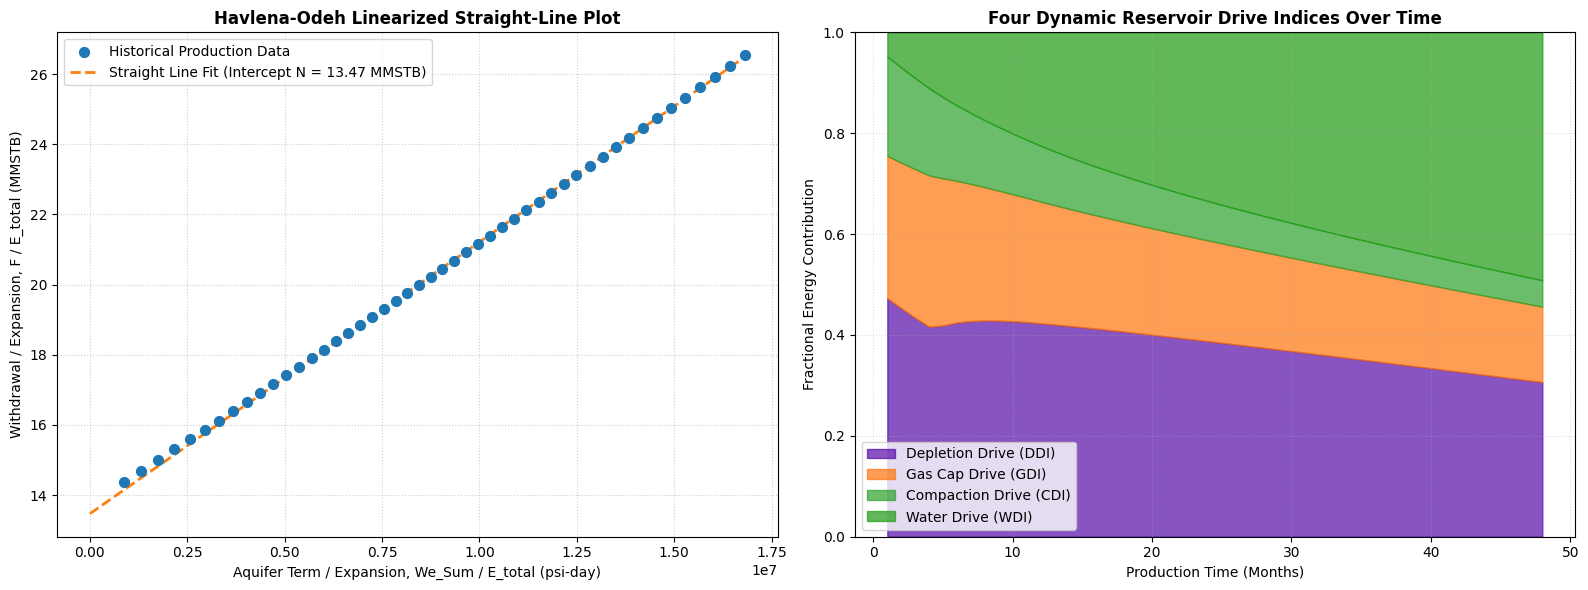

In [22]:
# Y-group = F / E_total (STB)
# X-group = We_Sum / E_total (psi-day)
df_history['Y_group'] = df_history['F'] / df_history['E_total']
df_history['X_group'] = df_history['We_Sum'] / df_history['E_total']

# Convert Y-group to MMSTB for a clean Y-axis scale
df_history['Y_group_MM'] = df_history['Y_group'] / 1e6

print(f"--- Full Combination Drive Material Balance Results ---")
print(f"Estimated OOIP (N): {N_estimated / 1e6:.2f} MMSTB")
print(f"Estimated Water Influx Constant (C): {C_water:.5f} bbl/psi-day")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Linearized Havlena-Odeh Straight Line Fit
# Plots Y-group vs X-group. Intercept on Y-axis is exactly OOIP (N)
ax1.scatter(df_history['X_group'], df_history['Y_group_MM'], color='#1F77B4', s=50, label='Historical Production Data', zorder=3)

# Fit line calculations: Y_fit = Intercept(N) + Slope(C) * X
x_fit = np.linspace(0, max(df_history['X_group']), 10)
y_fit_MM = (N_estimated / 1e6) + (C_water / 1e6) * x_fit
ax1.plot(x_fit, y_fit_MM, color='#FF7F0E', linestyle='--', linewidth=2, label=f'Straight Line Fit (Intercept N = {N_estimated/1e6:.2f} MMSTB)')

ax1.set_title('Havlena-Odeh Linearized Straight-Line Plot', fontsize=12, fontweight='bold')
ax1.set_xlabel('Aquifer Term / Expansion, We_Sum / E_total (psi-day)', fontsize=10)
ax1.set_ylabel('Withdrawal / Expansion, F / E_total (MMSTB)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Plot 2: Stacked Area Chart (DDI, GDI, CDI, WDI)
ax2.fill_between(df_history['Month'], 0, df_history['DDI'], color='#560BA7', alpha=0.7, label='Depletion Drive (DDI)')
ax2.fill_between(df_history['Month'], df_history['DDI'], df_history['DDI'] + df_history['GDI'], color='#FE740B', alpha=0.7, label='Gas Cap Drive (GDI)')
ax2.fill_between(df_history['Month'], df_history['DDI'] + df_history['GDI'], df_history['DDI'] + df_history['GDI'] + df_history['CDI'], color='#2CA02C', alpha=0.7, label='Compaction Drive (CDI)')
ax2.fill_between(df_history['Month'], df_history['DDI'] + df_history['GDI'] + df_history['CDI'], 1.0, color='#1F9B13', alpha=0.7, label='Water Drive (WDI)')
ax2.set_title('Four Dynamic Reservoir Drive Indices Over Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Production Time (Months)', fontsize=10)
ax2.set_ylabel('Fractional Energy Contribution', fontsize=10)
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle=':', alpha=0.4)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [23]:
# Nodal Analysis
H= params['well_depth']
ptf = params['wellhead_pressure']        # Wellhead flowing pressure (psi)
PI = params['productivity_index']       # Well Productivity Index in STB/day/psi
D = params['tubing_diameter']           # Tubing Inner Diameter (inches)
api_gravity = params['api_gravity'] 
f_friction = params.get('friction_factor', 0.02)  

# Dynamically calculate fluid density and specific gravity
sg_oil = 141.5 / (api_gravity + 131.5)
rho_oil = sg_oil * 62.4                 # Oil density in lb/ft3 (Water = 62.4 lb/ft3)
pb=pvt.pb


# IPR 
def calculate_IPR(pr,pb,J,points=100):
    # We will use Vogels IPR method for P<pb and normal st.line IPR for p>pb
    pwf_arr=np.linspace(0,pr,points)
    q_arr=[]
    # for undersaturated reservoir:
    if pr>=pb: # if res pressure is greater than pb
        qb=J * (pr-pb)
        qv = (J * pb) / 1.8  # Maximum possible Vogel flow rate below Pb

        for pwf in pwf_arr:
            if pwf>pb:
                q=J*(pr-pwf)
            else:
                q = qb + qv * (1.0 - 0.2 * (pwf / pb) - 0.8 * (pwf / pb)**2)
            q_arr.append(q)
    
    else: # res pressure less than bubble point
        qmax = (J * pr) / 1.8           # Maximum possible flow rate at zero pressure
        for pwf in pwf_arr:
            # Saturated reservoir flow (Pure Vogel curve)
            q = qmax * (1.0 - 0.2 * (pwf / pr) - 0.8 * (pwf / pr)**2)
            q_arr.append(q)
            
    return np.array(q_arr), pwf_arr

#VLP
def calculate_VLP(q_arr,ptf,H,D,rho_oil,f):
    #Pwf = Wellhead Pressure + Hydrostatic Loss + Frictional Loss
    hydrostatic_loss = (rho_oil * H) / 144.0
    frictional_loss = (1.84e-7 * f * rho_oil * H * (q_arr ** 2)) / (D ** 5)

    pwf_vlp = ptf + hydrostatic_loss + frictional_loss
    return pwf_vlp



def calculate_operating_point(q_ipr, pwf_ipr, ptf, H, D, rho_oil, f):

    pwf_vlp = calculate_VLP(q_ipr, ptf, H, D, rho_oil, f)

    diff = pwf_ipr - pwf_vlp

    # Find where the sign changes
    idx = np.where(np.diff(np.sign(diff)) != 0)[0]

    if len(idx) == 0:
        return None, None

    i = idx[0]

    # Linear interpolation between the two surrounding points
    q1, q2 = q_ipr[i], q_ipr[i+1]
    d1, d2 = diff[i], diff[i+1]

    q_op = q1 + (0 - d1) * (q2 - q1) / (d2 - d1)

    # Compute VLP pressure directly at q_op
    pwf_op = calculate_VLP(np.array([q_op]),ptf,H,D, rho_oil,f)[0]

    return q_op, pwf_op



Initial Stage (Pi) operating flow rate: 2441 bopd at Pwf = 1577 psi
Middle Stage (3200 psi) operating flow rate: 1518 bopd at Pwf = 1562 psi
Late Stage (1600 psi) operating flow rate: 56 bopd at Pwf = 1553 psi


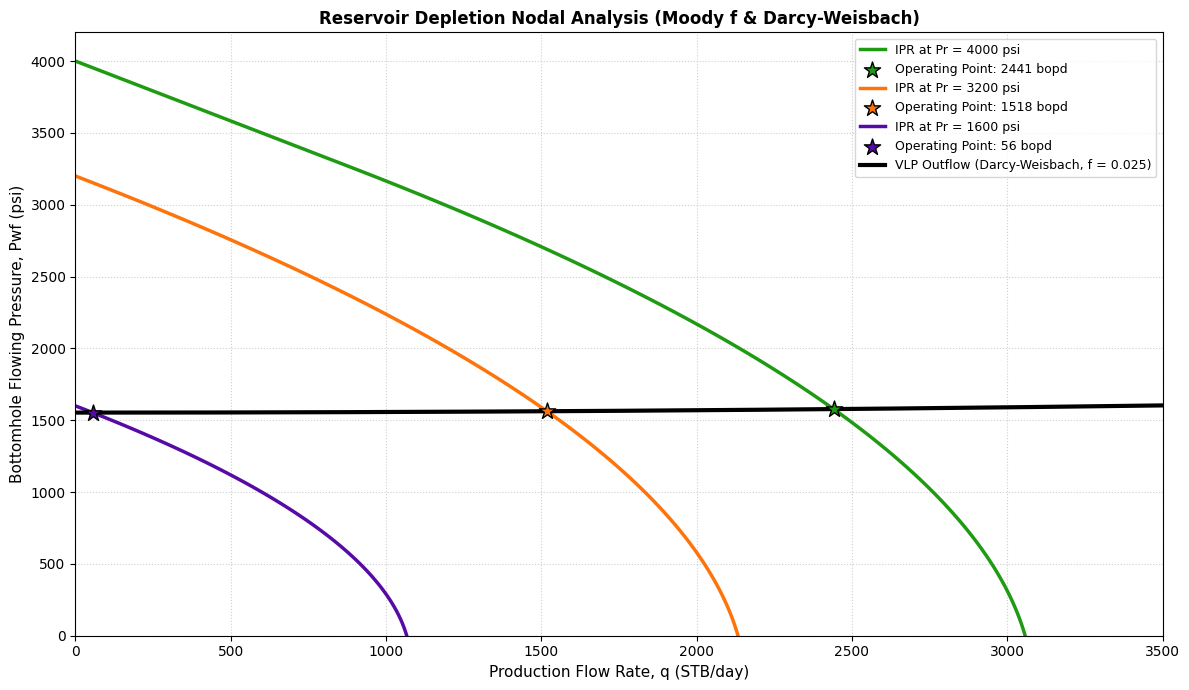

In [24]:
# Nodal Analysis Stages
pr_stages = {
    'Initial Stage (Pi)': pi,
    'Middle Stage (3200 psi)': pi * 0.8,
    'Late Stage (1600 psi)': pi * 0.4  # Adjusted to match 1600 psi in your plot
}

plt.figure(figsize=(12, 7))
colors = ['#1F9B13', '#FE740B', '#560BA7']

# Correct reference to pb from the PVT class
pb_val = pvt.pb

for i, (stage, pr) in enumerate(pr_stages.items()):
    # Call with correct bubble point reference
    q_ipr, pwf_ipr = calculate_IPR(pr, pb_val, PI)
    
    q_op, pwf_op = calculate_operating_point(q_ipr, pwf_ipr, ptf, H, D, rho_oil, f_friction)
    
    plt.plot(q_ipr, pwf_ipr, color=colors[i], linewidth=2.5, label=f'IPR at Pr = {pr:.0f} psi')
    
    # Only scatter the star if an intersection exists and the well flows
    if q_op is not None and q_op > 0:
        plt.scatter(q_op, pwf_op, color=colors[i], edgecolors='black', s=150, marker='*', zorder=4,
                    label=f'Operating Point: {q_op:.0f} bopd')
        print(f"{stage} operating flow rate: {q_op:.0f} bopd at Pwf = {pwf_op:.0f} psi")
    else:
        print(f"{stage}: Reservoir pressure ({pr:.0f} psi) is below VLP threshold. Well is dead.")

# Generate and plot the VLP curve
q_vlp_grid = np.linspace(0, 3500, 200)
pwf_vlp_grid = calculate_VLP(q_vlp_grid, ptf, H, D, rho_oil, f_friction)
plt.plot(q_vlp_grid, pwf_vlp_grid, color='black', linewidth=3, label=f'VLP Outflow (Darcy-Weisbach, f = {f_friction:.3f})', zorder=2)

# Chart Formatting
plt.title('Reservoir Depletion Nodal Analysis (Moody f & Darcy-Weisbach)', fontsize=12, fontweight='bold')
plt.xlabel('Production Flow Rate, q (STB/day)', fontsize=11)
plt.ylabel('Bottomhole Flowing Pressure, Pwf (psi)', fontsize=11)
plt.xlim(0, 3500)
plt.ylim(0, pi + 200)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
# DCA Modelling:
def arps_hyperbolic(t,qi,di,b):
    b = np.clip(b, 1e-5, 1.2)
    di = np.clip(di, 1e-5, 2.0)
    return qi / (1.0 + b * di * t) ** (1.0 / b)

# curve fitting the historical data:
t_hist = df_history['Month'].values
q_hist = df_history['Oil_Rate'].values

# Initial guesses for optimization
qi_guess = max(q_hist)
di_guess = 0.05
b_guess = 0.5

# Bounds: qi (10% to 200% of max), di (0.01% to 200%), b (0 to 1.2)
lower_bounds = [0.1 * qi_guess, 1e-4, 0.0]
upper_bounds = [2.0 * qi_guess, 2.0, 1.2]

try:
    popt, _ = curve_fit(
        arps_hyperbolic, t_hist, q_hist,
        p0=[qi_guess, di_guess, b_guess],
        bounds=(lower_bounds, upper_bounds),
        maxfev=10000
    )
    qi_fit, di_fit, b_fit = popt
except Exception as e:
    print(f"[WARNING] Fit failed, using fallback parameters: {e}")
    qi_fit, di_fit, b_fit = qi_guess, 0.05, 0.5


# production forecasting:
# Project production out to 120 months (10 years)

t_forecast = np.arange(1, 121)
q_forecast = arps_hyperbolic(t_forecast, qi_fit, di_fit, b_fit)

# cumulative oil produced till 36 monthes
cum_oil_produced = df_history['Cum_Oil'].iloc[-1]
# Calculate remaining reserves by integrating the forecast from Month 37 to 120
# Flow rate (bbl/day) is converted to monthly volume by multiplying by 30.4 days
remaining_reserves = np.sum(q_forecast[len(t_hist):]) * 30.4

# Estimated Ultimate Recovery (EUR)
eur = cum_oil_produced + remaining_reserves
# Recovery Factor (RF) based on our Material Balance Estimated OOIP (N_estimated)
recovery_factor = (eur / N_estimated) * 100


Fitted qi: 3000.0 STB/day
Fitted di: 3.00% per month
Fitted b-parameter: 0.400
Cumulative Oil Produced: 2.47 MMSTB
Remaining Forecasted Reserves: 1.22 MMSTB
Estimated Ultimate Recovery (EUR): 3.70 MMSTB
Calculated Recovery Factor (RF): 27.44%
 Automated Reservoir Sanity Audit:
  Dominant Mechanism: Water Drive (49% of energy at last history point)
 PASS: Recovery Factor (27.4%) is within expected limits for a Water Drive-dominated reservoir.
 PASS: Fitted decline exponent (b = 0.40) is within physically valid bounds (0-1).


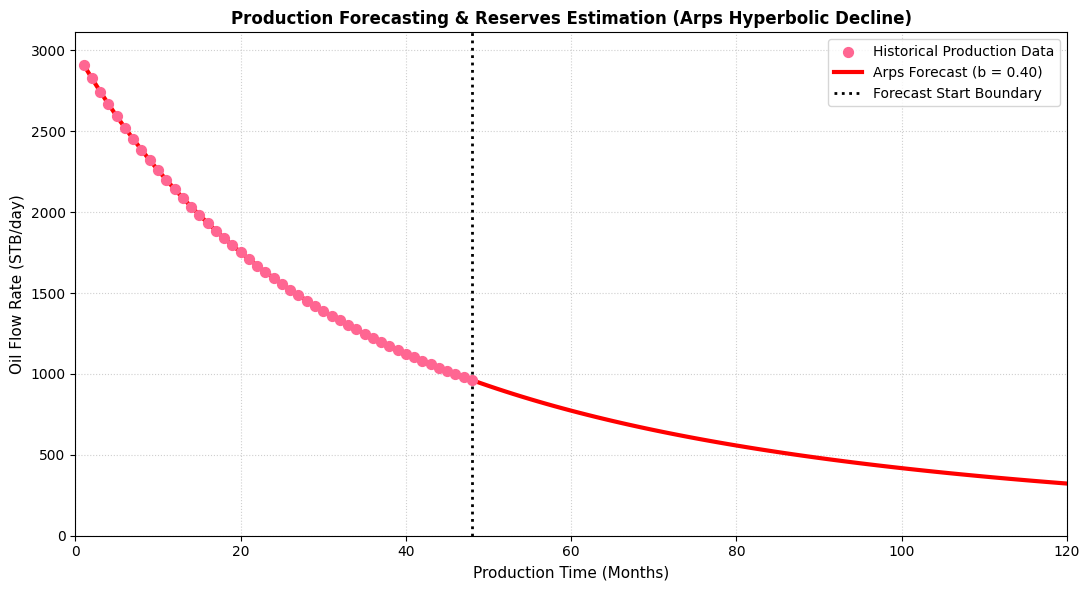

In [26]:
# visualization:
print(f"Fitted qi: {qi_fit:.1f} STB/day")
print(f"Fitted di: {di_fit * 100:.2f}% per month")
print(f"Fitted b-parameter: {b_fit:.3f}")

print(f"Cumulative Oil Produced: {cum_oil_produced / 1e6:.2f} MMSTB")
print(f"Remaining Forecasted Reserves: {remaining_reserves / 1e6:.2f} MMSTB")
print(f"Estimated Ultimate Recovery (EUR): {eur / 1e6:.2f} MMSTB")
print(f"Calculated Recovery Factor (RF): {recovery_factor:.2f}%")


# Dynamic Physics-based validation checks
drive_indices = {
    "Water Drive":      df_history['WDI'].iloc[-1],
    "Gas Cap Drive":    df_history['GDI'].iloc[-1],
    "Depletion Drive":  df_history['DDI'].iloc[-1],
    "Compaction Drive": df_history['CDI'].iloc[-1],
}
dominant_drive = max(drive_indices, key=drive_indices.get)
dominant_share = drive_indices[dominant_drive]
rf_bands = {
    "Water Drive":      (60.0, 75.0),  # strong aquifer + favorable mobility ratio can push higher
    "Gas Cap Drive":     (30.0, 45.0),
    "Depletion Drive":   (20.0, 35.0),
    "Compaction Drive":  (25.0, 40.0),
}
rf_warn, rf_fail = rf_bands[dominant_drive]
print(" Automated Reservoir Sanity Audit:")
print(f"  Dominant Mechanism: {dominant_drive} ({dominant_share*100:.0f}% of energy at last history point)")

if recovery_factor > rf_fail:
    print(f" FAIL: Recovery Factor ({recovery_factor:.1f}%) exceeds the realistic ceiling (~{rf_fail:.0f}%) "
          f"for a {dominant_drive}-dominated reservoir.")
    print("  Action: Constrain your DCA b-parameter, re-check N_estimated from the MBE fit, "
          "or verify the drive-index split above is correct.")
elif recovery_factor > rf_warn:
    print(f" WARNING: RF of {recovery_factor:.1f}% is high for a {dominant_drive}-dominated reservoir "
          f"(typical ceiling ~{rf_fail:.0f}%).")
    print("  Action: Check for unmodeled aquifer/compaction support or DCA over-prediction in the tail.")
else:
    print(f" PASS: Recovery Factor ({recovery_factor:.1f}%) is within expected limits for a "
          f"{dominant_drive}-dominated reservoir.")

if b_fit > 1.0:
    print(f" WARNING: b = {b_fit:.2f} exceeds the classical Arps limit (b <= 1.0) for a conventional reservoir.")
    print("  This usually signals transient/layered-reservoir effects rather than true "
          "boundary-dominated flow - worth a data-quality check, and consider tightening the "
          "curve_fit upper bound from 1.2 to 1.0 if this is meant to be a conventional reservoir.")
elif b_fit < 0.0:
    print(f" WARNING: b = {b_fit:.2f} is negative, which is non-physical for a declining well.")
else:
    print(f" PASS: Fitted decline exponent (b = {b_fit:.2f}) is within physically valid bounds (0-1).")


# 5. VISUALIZE DCA FORECAST
plt.figure(figsize=(11, 6))

# Plot historical production data points
plt.scatter(t_hist, q_hist, color='#FF6692', s=50, label='Historical Production Data', zorder=3)

# Plot full 10-year decline forecast
plt.plot(t_forecast, q_forecast, color='red', linewidth=3, label=f'Arps Forecast (b = {b_fit:.2f})', zorder=2)

# Draw a boundary line showing where the forecast begins
plt.axvline(x=len(t_hist), color='black', linestyle=':', linewidth=2, label='Forecast Start Boundary')

# Chart formatting
plt.title('Production Forecasting & Reserves Estimation (Arps Hyperbolic Decline)', fontsize=12, fontweight='bold')
plt.xlabel('Production Time (Months)', fontsize=11)
plt.ylabel('Oil Flow Rate (STB/day)', fontsize=11)
plt.xlim(0, 120)
plt.ylim(0, max(q_hist) + 200)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()